In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_f_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

# Island center & Shoaling depth

In [4]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [5]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

# Section domain into circles & quadrants

In [6]:
# # change to radial coordinate
# dis_c = np.zeros((len(data.x), len(data.y)))
# for i in range(len(data.x)):
#     for j in range(len(data.y)):
#         dis_c[i,j] = np.sqrt((data.x[i].data-x_c)**2+(data.y[j].data-y_c)**2)
        
# theta_c = np.zeros((len(data.x), len(data.y)))
# for i in range(len(data.x)):
#     for j in range(len(data.y)):
#         theta_c[i,j] = np.arctan2(data.y[j].data-y_c, data.x[i].data-x_c)

In [7]:
data_c = xr.open_dataset('../results_intermediate/dis_theta_c.nc')
dis_c = data_c.dis_c.data
theta_c = data_c.theta_c.data

In [8]:
dis_top = np.mean(dis_c[np.where((data_.depth>=depth_top+.1) & (data_.depth.data<=depth_top+2))])
dis_shoal = np.mean(dis_c[np.where((data_.depth>=depth_shoal-1) & (data_.depth.data<=depth_shoal+1))])
dis_bottom = np.mean(dis_c[np.where((data_.depth>=depth_bottom-1) & (data_.depth.data<depth_bottom))])
quadrants_info = {
    "r_quad": np.array([dis_top, dis_shoal,dis_bottom]),
    "quadrants": ['east', 'north', 'west', 'south'],
    "theta_edge":np.array([-45, 45, 135, -135]),
    "theta_quad": [[-45, 45], [45, 135], [135, -135], [-135, -45]]
            }

In [9]:
# mask out data outside of the inner ring
mask_ring_inner = (dis_c>=quadrants_info["r_quad"][0]) & (dis_c<quadrants_info["r_quad"][1])
mask_ring_inner_east = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_inner_north = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_inner_west = mask_ring_inner & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_inner_south = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# mask out data outside of the outer ring
mask_ring_outer = (dis_c>=quadrants_info["r_quad"][1]) & (dis_c<quadrants_info["r_quad"][-1])
mask_ring_outer_east = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_outer_north = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_outer_west = mask_ring_outer & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_outer_south = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# Barotropic velocity

In [10]:
# read data
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [11]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

## transform to cylindrical coordinates

In [12]:
def cart_to_cyl(u,v,theta):
    """ this function transforms a cartesian vector u,v to cylindrical coordinates u_r, u_theta, with angle theta (rad)
    """
    u_r = u * np.cos(theta) + v * np.sin(theta)
    u_theta = -u * np.sin(theta) + v * np.cos(theta)
    return u_r, u_theta

In [13]:
# transform to cylindrical coordinates
U_r = np.zeros(U.shape) + np.nan
U_theta = np.zeros(U.shape) + np.nan
for i in range(U.shape[0]):
    U_r[i,:,:], U_theta[i,:,:] = cart_to_cyl(U[i,:,:], V[i,:,:], theta_c)

## time-integration

In [14]:
data["U_r"]=(['time', 'x', 'y'],  U_r)
data["U_theta"]=(['time', 'x', 'y'],  U_theta)

In [15]:
U_r_int = data.U_r.integrate('time',datetime_unit="s")
U_theta_int = data.U_theta.integrate('time',datetime_unit="s")

In [16]:
data["U"]=(['time', 'x', 'y'],  U)
data["V"]=(['time', 'x', 'y'],  V)

In [17]:
U_int = data.U.integrate('time',datetime_unit="s")
V_int = data.V.integrate('time',datetime_unit="s")

# overhead view

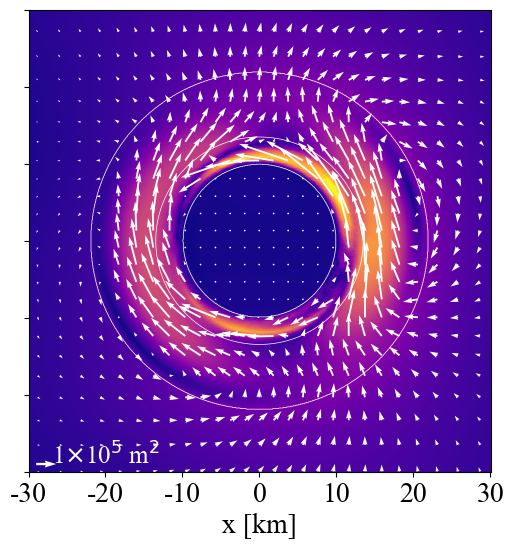

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))
im1 = (np.sqrt(U_int**2+V_int**2)*data_.depth).T.plot.pcolormesh(ax=ax, vmax=3e5, vmin=0, cmap=cm.plasma, add_colorbar=False)
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='w', linewidths=.5)
ax.quiver(data.x.data[::40], data.y.data[::40], (U_int[::40,::40]*data_.depth[::40,::40].data).T, (V_int[::40,::40]*data_.depth[::40,::40].data).T, scale=5e5, scale_units='inches', width=4e-3, color='w')

ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_yticklabels('')
# ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=20)
# ax.set_ylabel('y [km]', fontsize=20)
ax.set_ylabel('')
ax.set_title(f'')
ax.tick_params(axis='both', which='major', labelsize=20)
plt.rcParams["font.family"] = "Times New Roman"
ax.quiver(x_c-30000+1000, y_c-30000+1000, 1e5, 0, color='w', scale=5e5, scale_units='inches', width=5e-3)
ax.text(x_c-30000+3000, y_c-30000+1000,r'1$\times$10$^5$ m$^2$',color='w', fontsize=18)

plt.savefig(outfilepath+ f"UVH_int_overhead_summer_f.png", transparent = True, dpi=300)